In [19]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Last 8 RBI Policy Dates
rbi_dates = [
    '2024-02-08',
    '2024-04-05',
    '2024-06-07',
    '2024-08-08',
    '2024-10-09',
    '2024-12-06',
    '2025-02-07',
    '2025-04-09',
]

print("RBI Dates loaded:", len(rbi_dates))

# Pull Nifty historical data
nifty = yf.Ticker("^NSEI")
hist = nifty.history(start="2024-01-01", end="2025-06-01")
print("Nifty data shape:", hist.shape)
print(hist.tail())

RBI Dates loaded: 8
Nifty data shape: (348, 7)
                                   Open          High           Low  \
Date                                                                  
2025-05-26 00:00:00+05:30  24919.349609  25079.199219  24900.500000   
2025-05-27 00:00:00+05:30  24956.650391  25062.900391  24704.099609   
2025-05-28 00:00:00+05:30  24832.500000  24864.250000  24737.050781   
2025-05-29 00:00:00+05:30  24825.099609  24892.599609  24677.300781   
2025-05-30 00:00:00+05:30  24812.599609  24863.949219  24717.400391   

                                  Close  Volume  Dividends  Stock Splits  
Date                                                                      
2025-05-26 00:00:00+05:30  25001.150391  302800        0.0           0.0  
2025-05-27 00:00:00+05:30  24826.199219  525700        0.0           0.0  
2025-05-28 00:00:00+05:30  24752.449219  684400        0.0           0.0  
2025-05-29 00:00:00+05:30  24833.599609  345400        0.0           0.0  
2025-

In [20]:
import numpy as np

# Calculate 10-day rolling Historical Volatility
hist['returns'] = hist['Close'].pct_change()
hist['HV10'] = hist['returns'].rolling(10).std() * np.sqrt(252) * 100

print(hist[['Close', 'HV10']].tail(10))

                                  Close       HV10
Date                                              
2025-05-19 00:00:00+05:30  24945.449219  23.993466
2025-05-20 00:00:00+05:30  24683.900391  24.701969
2025-05-21 00:00:00+05:30  24813.449219  24.779730
2025-05-22 00:00:00+05:30  24609.699219  25.016720
2025-05-23 00:00:00+05:30  24853.150391  24.293271
2025-05-26 00:00:00+05:30  25001.150391  15.073466
2025-05-27 00:00:00+05:30  24826.199219  13.571359
2025-05-28 00:00:00+05:30  24752.449219  13.624409
2025-05-29 00:00:00+05:30  24833.599609  10.720169
2025-05-30 00:00:00+05:30  24750.699219  10.786160


In [21]:
# Fix HV calculation
hist = hist.copy()
hist['returns'] = hist['Close'].pct_change()
hist['HV10'] = hist['returns'].rolling(10).std() * np.sqrt(252) * 100

# Check values
print("HV10 sample:")
print(hist['HV10'].dropna().head(20))
print("\nHV10 stats:")
print(hist['HV10'].describe())

HV10 sample:
Date
2024-01-15 00:00:00+05:30    10.532969
2024-01-16 00:00:00+05:30    10.460907
2024-01-17 00:00:00+05:30    15.045290
2024-01-18 00:00:00+05:30    14.820748
2024-01-19 00:00:00+05:30    15.341698
2024-01-23 00:00:00+05:30    17.216277
2024-01-24 00:00:00+05:30    18.121137
2024-01-25 00:00:00+05:30    18.105619
2024-01-29 00:00:00+05:30    20.532127
2024-01-30 00:00:00+05:30    20.141032
2024-01-31 00:00:00+05:30    20.170505
2024-02-01 00:00:00+05:30    20.157135
2024-02-02 00:00:00+05:30    17.304211
2024-02-05 00:00:00+05:30    17.178222
2024-02-06 00:00:00+05:30    17.157268
2024-02-07 00:00:00+05:30    13.520485
2024-02-08 00:00:00+05:30    14.330537
2024-02-09 00:00:00+05:30    13.946282
2024-02-12 00:00:00+05:30    11.425825
2024-02-13 00:00:00+05:30    10.511471
Name: HV10, dtype: float64

HV10 stats:
count    338.000000
mean      13.252084
std        6.643310
min        3.584787
25%        9.705480
50%       11.847948
75%       14.679773
max       42.132415
Na

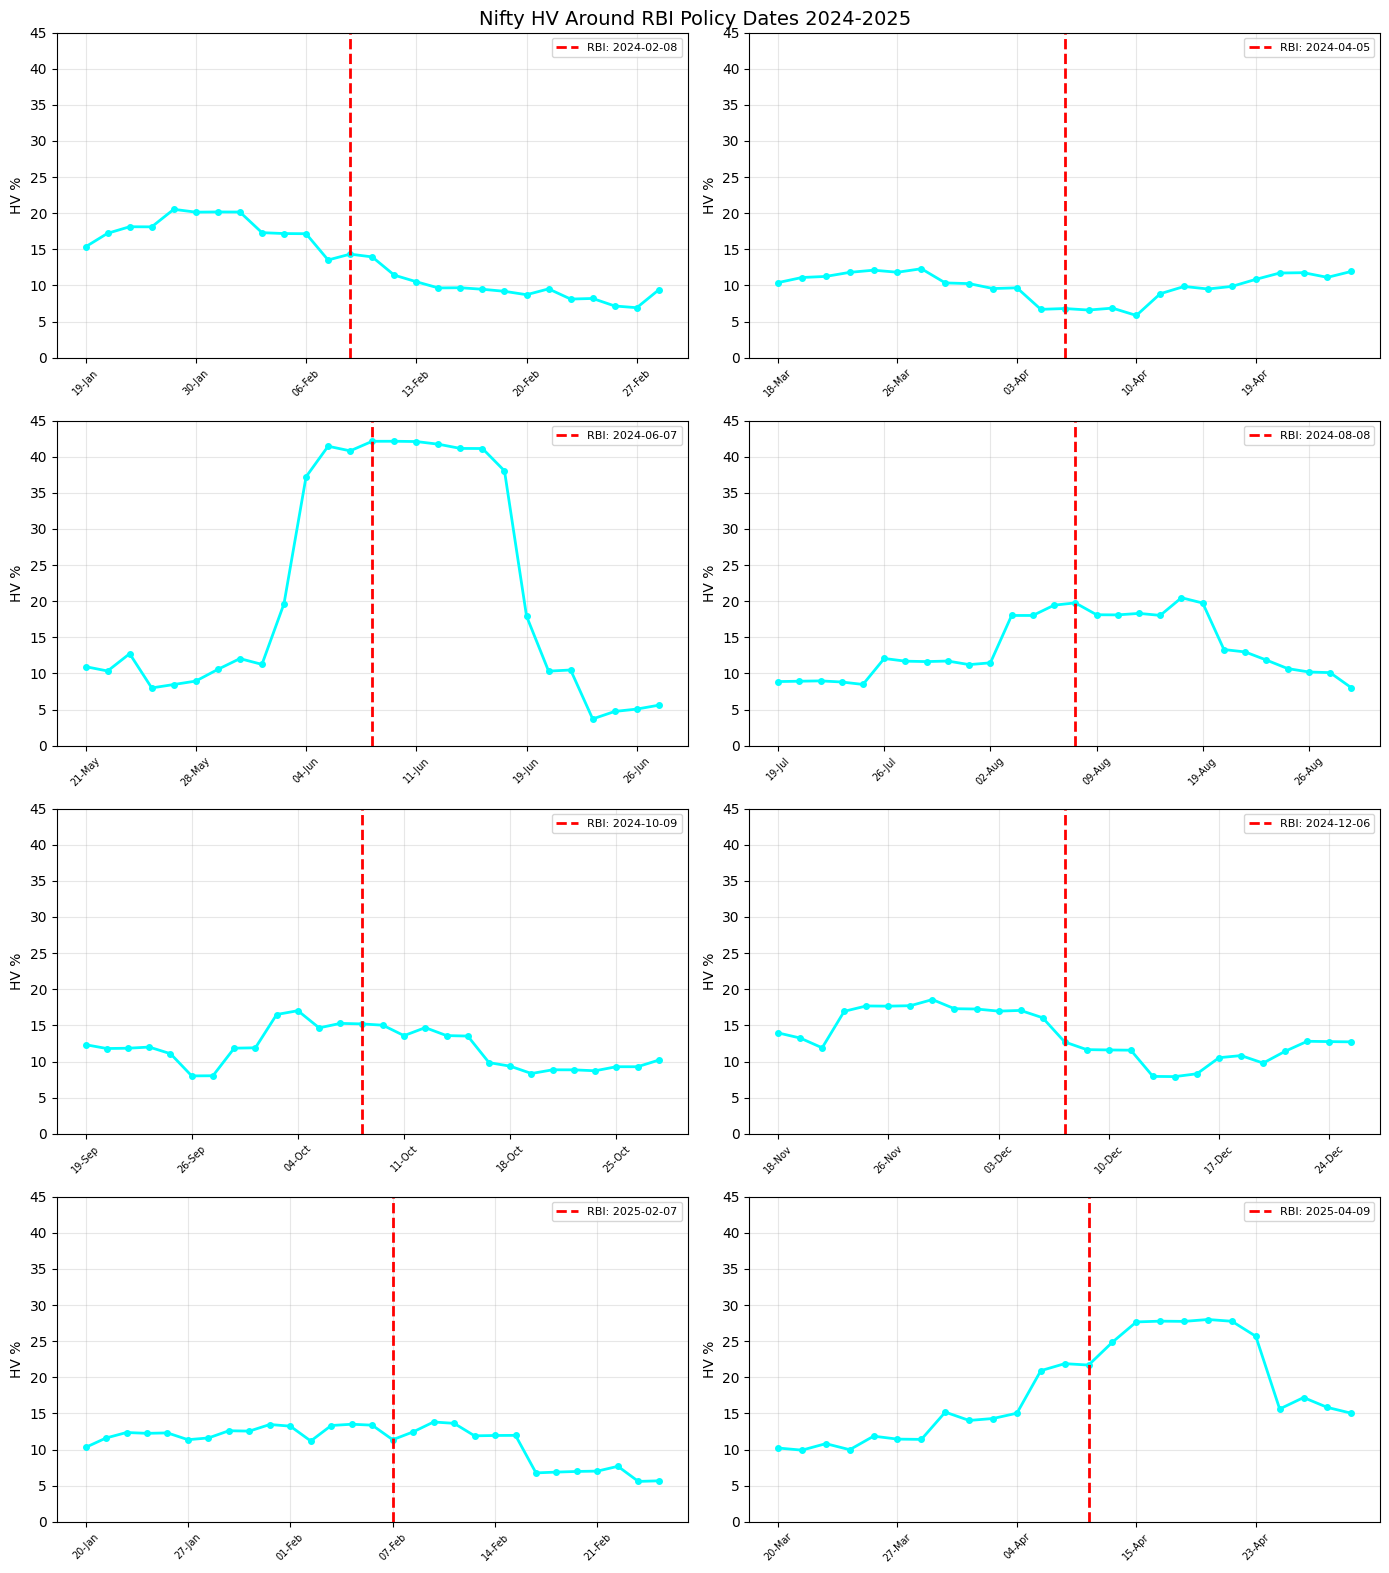

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, date in enumerate(rbi_dates):
    rbi_date = pd.Timestamp(date).tz_localize('Asia/Kolkata')

    start = rbi_date - pd.Timedelta(days=20)
    end = rbi_date + pd.Timedelta(days=20)

    window = hist[(hist.index >= start) & (hist.index <= end)][['HV10']].dropna()

    if len(window) > 0:
        # Reset index to get clean dates
        window = window.reset_index()
        window['day'] = range(len(window))

        # Find exact RBI date position
        rbi_pos = window[window['Date'].dt.date >= rbi_date.date()]['day'].iloc[0]

        axes[i].plot(window['day'], window['HV10'],
                    color='cyan', linewidth=2, marker='o', markersize=4)
        axes[i].axvline(x=rbi_pos, color='red', linestyle='--',
                       linewidth=2, label=f'RBI: {date}')

        # Add date labels on x axis
        step = max(1, len(window)//5)
        tick_positions = window['day'][::step].values
        tick_labels = window['Date'][::step].dt.strftime('%d-%b').values
        axes[i].set_xticks(tick_positions)
        axes[i].set_xticklabels(tick_labels, rotation=45, fontsize=7)

        axes[i].set_ylabel('HV %')
        axes[i].set_ylim(0, 45)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Nifty HV Around RBI Policy Dates 2024-2025', fontsize=14)
plt.tight_layout()
plt.suptitle('Nifty HV Around RBI Policy Dates 2024-2025', fontsize=14)
plt.tight_layout()
plt.savefig('iv_event_study.png', dpi=150, bbox_inches='tight')  # ADD THIS
plt.show()

## Nifty IV Event Study — RBI Policy Dates 2024-2025

### Research Question
Does Nifty implied volatility consistently spike before RBI policy
announcements and crush after?

### Key Finding
IV behavior around RBI dates is NOT uniform — it depends on:
1. Whether the outcome was expected or surprising
2. Concurrent macro events (elections, Fed, oil prices)
3. Whether a rate change cycle is beginning or continuing

### Event-by-Event Analysis

*08 Feb 2024 — Rate Unchanged (6.5%)*
HV rose before as market uncertain about first cut timing.
Dropped after — no cut confirmed, uncertainty resolved.
Option sellers profited from IV crush.

*05 Apr 2024 — Rate Unchanged (6.5%)*
IV rose only moderately — outcome fully expected.
Dropped after announcement. Fully priced-in events = muted IV spike.

*07 Jun 2024 — Rate Unchanged (6.5%)*
HV rose significantly — DOUBLE uncertainty event.
Election results (Jun 4) + RBI announcement created compounded volatility.
Sharp drop after both events resolved.

*08 Aug 2024 — Rate Unchanged (6.5%)*
IV rose due to global factors — US Fed uncertainty, oil price
fluctuations, India stretched valuations.
Dropped after RBI confirmed status quo.

*09 Oct 2024 — Rate Unchanged (6.5%)*
Food inflation risk (India-specific) kept market nervous.
RBI tone cautious on inflation — no cut signals.
IV elevated before, dropped after hawkish-but-unchanged outcome.

*06 Dec 2024 — Rate Unchanged (6.5%)*
Market had started pricing in future cuts — rate cut expectations building.
RBI gave no signal — disappointed market.
IV rose into event, dropped after no-signal outcome.

*07 Feb 2025 — RATE CUT 6.5% → 6.25%*
First cut after long pause — surprise to many.
Entire yield curve repriced. Banking sector rallied.
IV spiked POST event — unexpected outcome created new uncertainty
about pace of future cuts.

*09 Apr 2025 — RATE CUT 6.25% → 6.00%*
Second cut — now expected, rate cut cycle confirmed.
IV did not spike significantly before or after.
Fully priced-in events produce muted volatility response.

### Conclusion
IV spikes before RBI when outcome is uncertain.
IV crushes after when uncertainty resolves.
When outcome is fully expected — IV behavior is muted.
The Feb 2025 cut broke the pattern — post-event IV spike due to
yield curve repricing and new uncertainty about cut pace.

### Trading Implication
Selling options just before RBI when outcome is highly expected =
capturing IV crush with limited risk.
Avoid short volatility positions when macro backdrop is uncertain
(elections, Fed, oil shocks).

